## در این مثال یک کمپرسور بدلیل جریان بالای موتور متوقف می شود. دیتاست با داده های زمانی شامل فشار روغن، دبی روغن، دمای روغن، ارتعاش یاتاقان و جریان موتور جمع آوری شده و داده کاوی علی برای شناسایی ریشه واقعی مشکل انجام می شود.
دیتاست را دانلود و در پوشه کاری قرار دهید.
compressor_data.csv

!pip install causal-learn networkx

### فراخوانی کتابخانه های مورد نیاز

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

### فراخوانی داده و پیش پردازش

In [2]:
df = pd.read_csv('compressor_data.csv')
data = df[['oil_pressure','oil_flow', 'temperature', 'motor_current', 'bearing_vibration']].values
variables = ['oil_pressure','oil_flow', 'temperature', 'motor_current', 'bearing_vibration']

### تحلیل علیت گرنجری و ساخت گراف

این تحلیل یک آزمون فرضیه های آماری است که برای بررسی پیش بینی پذیری بین سری های زمانی بکار می رود. اگر سری زمانی الف بتواند سری ب را بهتر از وقتی که فقط از مقادیر گذشته ب استفاده می شود، پیش بینی کند، آنگاه الف علت گرنچری ب است. فرض اصلی روش گرنچر "علت مقدم بر معلول است" یعنی گذشته می تواند حال و آینده را پیش بینی کند و نه برعکس

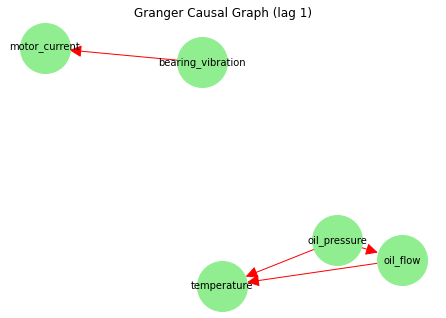

In [9]:
max_lag = 10 # تعداد تاخیر براساس پویایی سیستم انتخاب می شود
G_granger = nx.DiGraph()
G_granger.add_nodes_from(variables)

for cause in variables:
    for effect in variables:
        if cause == effect:
            continue
        test_data = df[[effect, cause]].dropna()
        # ازمون گرنجری
        try:
            result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
            # بررسی p-value برای تاخیر شماره 2
            p_value = result[2][0]['ssr_ftest'][1] # آزمون F
            if p_value < 0.05:
                G_granger.add_edge(cause, effect)
        except:
            pass

# ترسیم گراف
pos = nx.spring_layout(G_granger, seed=42)
nx.draw(G_granger, pos, with_labels=True, node_color='lightgreen',
       edge_color='red', node_size=2500, font_size=10,
       arrows=True, arrowsize=25)
plt.title('Granger Causal Graph (lag 1)')
plt.show()

با توجه به گراف، ارتباط بین ارتعاش بیرینگ و جریان موتور وجود دارد. از طرفی دیگر ارتباطی بین فشار روغن و جریان روغن، فشار روغن و دما، و جریان روغن و دمای روغن وجود دارد. با دانش دامنه می توان گفت احتمال دارد ارتباطی بین دما و ارتعاش بیرینگ وجود داشته باشد ولی در این گراف دیده نمی شود. از اینرو باید بررسی های بیشتری صورت گیرد.

### بررسی همبستگی دما و ارتعاش

In [12]:
temp = df['temperature'].values
vib = df['bearing_vibration'].values

بیشترین همبستگی: 0.765 در lag=158


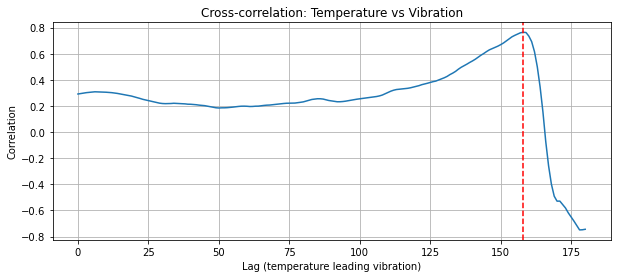

In [13]:
# محاسبه همبستگی برای تاخیرهای 0 تا 180
max_lag = 180
corrs = []
for lag in range(0, max_lag+1):
    # دمای گذشته (lag نمونه قبل) و ارتعاش فعلی
    corr = np.corrcoef(temp[:len(temp)-lag], vib[lag:])[0,1]
    corrs.append(corr)

best_lag = np.argmax(corrs)
print(f"بیشترین همبستگی: {corrs[best_lag]:.3f} در lag={best_lag}")

plt.figure(figsize=(10,4))
plt.plot(range(0,max_lag+1), corrs)
plt.xlabel('Lag (temperature leading vibration)')
plt.ylabel('Correlation')
plt.title('Cross-correlation: Temperature vs Vibration')
plt.axvline(best_lag, color='r', linestyle='--')
plt.grid(True)
plt.show()

با توجه به اینکه پدیده های فیزیکی می تواند پس از تاخیر مشخصی بر پدیده دیگر تاثیر گذار باشد. نمودار همبستگی در تاخیرهای مختلف رسم گردید و مقدار همبستگی در 158 بیشترین خود را نشان داد.

### ساخت ویژگی تاخیردار و اثبات رابطه بین آن ها

In [14]:
lag = best_lag  # 158
df['temp_lagged'] = df['temperature'].shift(lag)
df_clean = df.dropna()

# ضریب همبستگی پیرسون و اسپیرمن
from scipy.stats import pearsonr, spearmanr
r_p, p_p = pearsonr(df_clean['temp_lagged'], df_clean['bearing_vibration'])
r_s, p_s = spearmanr(df_clean['temp_lagged'], df_clean['bearing_vibration'])
print(f"Pearson r={r_p:.3f}, p={p_p:.5f}")
print(f"Spearman r={r_s:.3f}, p={p_s:.5f}")

# رگرسیون خطی ساده
from sklearn.linear_model import LinearRegression
X = df_clean[['temp_lagged']]
y = df_clean['bearing_vibration']
model = LinearRegression().fit(X, y)
print(f"R² = {model.score(X,y):.3f}, coefficient = {model.coef_[0]:.3f}")

Pearson r=0.765, p=0.00000
Spearman r=0.191, p=0.22607
R² = 0.585, coefficient = 2.072


براساس داده ها، شاخص پیرسون 0.765 همبستگی خطی قوی را نشان می دهد و مقدار p_value نزدیک به صفر نیز از نظر آماری کاملا معنی دار است.
اما شاخص اسپیرمن 0.191 همبستگی رتبه ای ضعیفی نشان میدهد که با مقدار p_value 0.226 از نظر آماری معنی دار نیست. 
R2 0.585 نشان میدهد که دمای 158 نمونه قبل 58.8درصد از تغییرات ارتعاش را توضیح می دهد.
و ضریب مدل 2.072 به معنی آن است که هر یک درجه افزایش دما (در آن زمان) با 2.07 افزایش ارتعاش همراه است.
دانش دامنه به ما میگوید که افزایش دما می تواند باعث کاهش مقاومت سایشی و افزایش سایش یاتاقان و خرابی آن می شود 

### ساخت گراف نهایی
با توجه به نتایج تحلیل گرنجی قبلی و تحلیل همبستگی، گراف نهایی را برای نمایش می سازیم. 
افزودن نتایج گرنجی قبلی و افزودن ارتباط بین دما و ارتعاش با سپس با تاخیر 158.

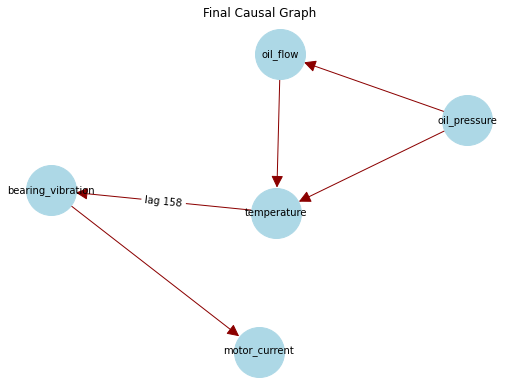

In [17]:
G = nx.DiGraph()
nodes = ['oil_pressure', 'oil_flow', 'temperature', 'bearing_vibration', 'motor_current']
G.add_nodes_from(nodes)

# یال های اثبات شده از بررسی قبل (بدون تاخیر)
G.add_edge('oil_pressure', 'oil_flow')
G.add_edge('oil_pressure', 'temperature')
G.add_edge('oil_flow', 'temperature')
G.add_edge('bearing_vibration', 'motor_current')

# یال تاخیری (با برچسب تاخیر)
G.add_edge('temperature', 'bearing_vibration', label=f'lag {lag}')

pos = nx.spring_layout(G, seed=10)
plt.figure(figsize=(7,5))
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        edge_color='darkred', node_size=2500, font_size=10,
        arrows=True, arrowsize=25)
# اضافه کردن برچسب یال
edge_labels = {('temperature','bearing_vibration'): f'lag {lag}'}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title('Final Causal Graph')
plt.show()

#### با توجه به ارتباطات مشخص شده، مشکل توقف ناشی از جریان موتور به علت فشار روغن بوده و با بررسی فشار روغن عواملی چون افت فشار در فیلتر روغن به عنوان ریشه اصلی خرابی معرفی گردید